In [1]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
%pip install -e ..

In [2]:
from proj2dhullsampler import Prep_Mask_Generation
from proj2dhullsampler.prep_class import meta_one_hot_shot

In [3]:
working_dir = '/glade/work/qingyuany/camml_re'
case_name = "test"


#dict for cam7
# obs_dict = {'RESTOM': 'toa_net_all_mon',
#  'FSNT': 'fsnt',
#  'FLNT': 'toa_lw_all_mon',
#  'SWCF': 'toa_cre_sw_mon',
#  'LWCF': 'toa_cre_lw_mon',
#  'PRECT': 'PRECT',
#  'TGCLDLWP': 'TGCLDLWP',
#  'FSNTC': 'toa_sw_clr_t_mon',
#  'FLUTC': 'toa_lw_clr_t_mon',
#  'TMQ': 'PREH2O',
#  'LHFLX': 'LHFLX'}


#dict for camml:
#
obs_dict = {"SWCF": "swcrf_toa", "LWCF": "lwcrf_toa", "TGCLDLWP": "clwp", "TMQ": "pwv",
          "FLUT": "olr", "PRECT": "pr","FSNTOA": "swabs_toa"}


In [4]:

ppe = xr.open_dataset("/glade/work/qingyuany/camml_re/v0/initial_ppe.nc")
#obs = xr.open_dataset("/glade/work/qingyuany/camml_re/obs.nc")

obs = xr.open_dataset("~/satellite_obs/obs_interp_cam6.nc")
obs['pr'] = obs['pr']/(1000 * 86400)


In [ ]:
#ppe = None

In [5]:
para = xr.open_dataset("/glade/work/qingyuany/camml_re/v0/parameter_34_100.nc")
para = para.to_dataframe().drop(columns = 'Sample_nmb')
para.index = para.index +1



In [ ]:

# obs_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v0/obs_precip_freq.csv', index_col = 0)
# obs_precip_freq = obs_precip_freq.iloc[:,0]

# ppe_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v1_b/post_simulations/added_precip.csv', index_col=0)

In [6]:
lat_bins = np.arange(-75, 76, 5)  # -90 to 90 every 10 degrees

In [7]:
lab_bin_labels = np.char.add(np.char.add(lat_bins[:-1].astype(str), "to"), lat_bins[1:].astype(str))

In [8]:
man_sel_locations1 = pd.Series({"nm": "PRECT", "lat_min": 4,"lat_max": 7, "lon_min":  1, "lon_max": 359})

manul_ppe_info = pd.concat([man_sel_locations1], axis  = 1).transpose()
manul_ppe_info

,nm,lat_min,lat_max,lon_min,lon_max
0,PRECT,4,7,1,359


In [9]:
test_case = Prep_Mask_Generation(working_dir, case_name, ppe, obs, obs_dict, para, lat_bins, manul_ppe_info)

Parameter and simulation indices match
nan variables matching between obs and simulation
Zonalized and manually selected obs and ppe written as csv


In [10]:
test_case.sensitivity_emulation(n_cpus = 10)
test_case.mask_generation()

/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

In [11]:
meta_table = meta_one_hot_shot(test_case.meta, test_case.data_gcm.para_nm)

In [12]:
meta_table.shape

(210, 34)

In [13]:
meta_table

,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,clubb_c11,...,zmconv_capelmt,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale
SWCF_zonal_-75to-70,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
SWCF_zonal_-70to-65,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
SWCF_zonal_-65to-60,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
SWCF_zonal_-60to-55,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
SWCF_zonal_-55to-50,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FSNTOA_zonal_55to60,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
FSNTOA_zonal_60to65,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
FSNTOA_zonal_65to70,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
FSNTOA_zonal_70to75,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True


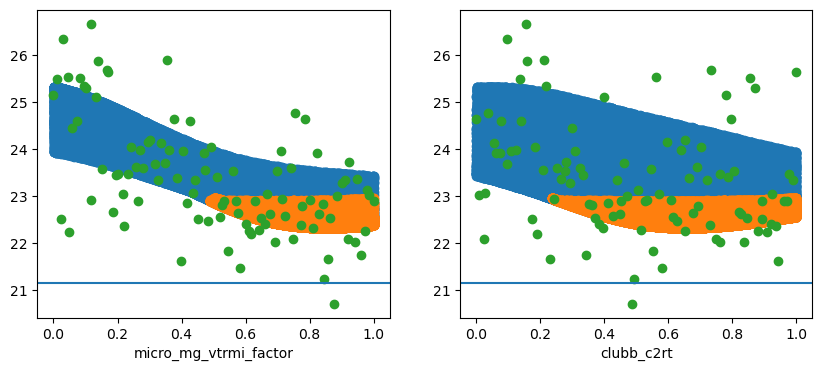

In [20]:
test_case.visualize_check('TMQ_zonal_-35to-30')

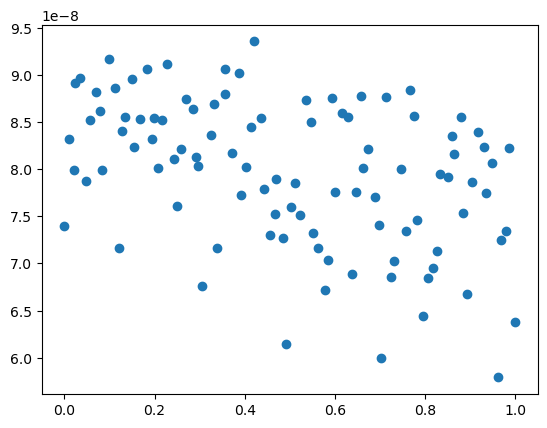

In [21]:
import matplotlib.pyplot as plt
plt.scatter(test_case.data_gcm.para_norm.micro_mg_dcs, test_case.data_gcm.ppe_pd['PRECT_zonal_5to10'])

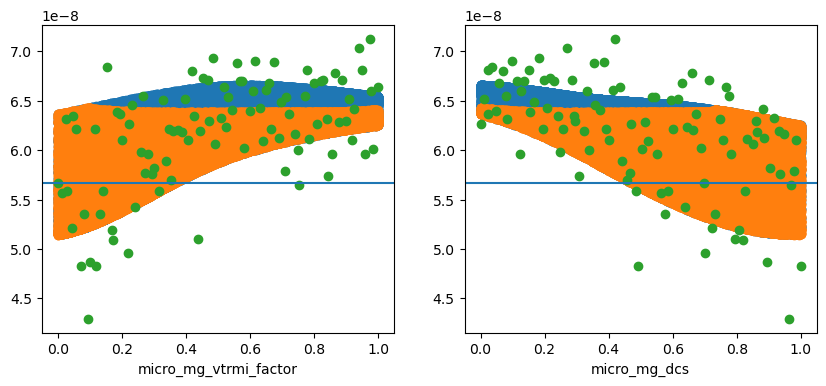

In [25]:
test_case.visualize_check('PRECT_zonal_5to15')